This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## A deep dive on Keras

### A spectrum of workflows

### Different ways to build Keras models

#### The Sequential model

In [3]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [4]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax")) 

In [5]:
model.weights

[]

In [6]:
model.build(input_shape=(None, 3))
model.weights

[<Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[ 0.13572921  0.23846944  0.1510022  -0.13440557  0.02514576  0.19673447
   -0.24124728  0.07720441  0.06994224 -0.06774117  0.08810408 -0.0855674
    0.18273018  0.13367611  0.15110095  0.05822806 -0.09793362  0.17315507
   -0.19068286 -0.28195518  0.24322167 -0.07562328 -0.04972866 -0.12405057
   -0.2281922  -0.20485196 -0.11939014  0.15838766  0.13725261 -0.0770802
   -0.19445564  0.13686049  0.1536469   0.21796332 -0.21419069 -0.12722774
   -0.06122302  0.2325553  -0.2171932  -0.0230983  -0.11934862  0.18834916
   -0.06992669 -0.02730345 -0.02195524 -0.1552246  -0.16961852  0.04578329
    0.20441467 -0.18390934 -0.16588007 -0.14441705  0.0427862  -0.25252566
    0.13707153 -0.16300982 -0.2781839   0.24430345  0.03737428  0.09846095
    0.17610486  0.01236422  0.13884646 -0.17553487]
  [-0.17099945  0.07339303 -0.17809075 -0.27990994 -0.27201757 -0.02986603
   -0.29107127 -0.08410813 -0.1542139  -0.068

In [7]:
model.summary(line_length=80)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary(line_length=80)

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)            │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ my_last_layer (Dense)             │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

In [10]:
model.summary(line_length=80)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                   │ (None, 64)               │           256 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.add(layers.Dense(10, activation="softmax"))
model.summary(line_length=80)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_5 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

#### The Functional API

##### A simple example

In [12]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

In [13]:
inputs = keras.Input(shape=(3,), name="my_input")

In [14]:
inputs.shape

(None, 3)

In [15]:
inputs.dtype

'float32'

In [16]:
features = layers.Dense(64, activation="relu")(inputs)

In [17]:
features.shape

(None, 64)

In [18]:
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

In [19]:
model.summary(line_length=80)

Model: "my_functional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)             │ (None, 3)                │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_8 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_9 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

##### Multi-input, multi-output models

In [20]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu", name="dense_features")(features)

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(
    num_departments, activation="softmax", name="department"
)(features)

model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department],
)

##### Training a multi-input, multi-output model

In [21]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, num_departments, size=(num_samples, 1))

model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
model.fit(
    [title_data, text_body_data, tags_data],
    [priority_data, department_data],
    epochs=1,
)
model.evaluate(
    [title_data, text_body_data, tags_data], [priority_data, department_data]
)
priority_preds, department_preds = model.predict(
    [title_data, text_body_data, tags_data]
)

/Users/jungwoo/.pyenv/versions/cau-2026-DL/lib/python3.14/site-packages/jax/_src/core.py:1976: UserWarning: Explicitly requested dtype int64 requested in ShapeDtypeStruct is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return aval_fn(x)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - department_accuracy: 0.2680 - department_loss: 8.6219 - loss: 8.9566 - priority_loss: 0.3347 - priority_mean_absolute_error: 0.5021
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - department_accuracy: 0.3031 - department_loss: 8.0980 - loss: 8.4386 - priority_loss: 0.3405 - priority_mean_absolute_error: 0.5081
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step


In [22]:
model.compile(
    optimizer="adam",
    loss={
        "priority": "mean_squared_error",
        "department": "sparse_categorical_crossentropy",
    },
    metrics={
        "priority": ["mean_absolute_error"],
        "department": ["accuracy"],
    },
)
model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
    epochs=1,
)
model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
)
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - department_accuracy: 0.2617 - department_loss: 11.8562 - loss: 12.1902 - priority_loss: 0.3340 - priority_mean_absolute_error: 0.5019
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - department_accuracy: 0.2586 - department_loss: 11.9501 - loss: 12.2743 - priority_loss: 0.3242 - priority_mean_absolute_error: 0.4919
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step


##### The power of the Functional API: Access to layer connectivity

###### Plotting layer connectivity

In [23]:
keras.utils.plot_model(model, "ticket_classifier.png")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [24]:
keras.utils.plot_model(
    model,
    "ticket_classifier_with_shape_info.png",
    show_shapes=True,
    show_layer_names=True,
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


###### Feature extraction with a Functional model

In [25]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_features, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [26]:
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [27]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>

In [28]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags], outputs=[priority, department, difficulty]
)

In [29]:
keras.utils.plot_model(
    new_model,
    "updated_ticket_classifier.png",
    show_shapes=True,
    show_layer_names=True,
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


#### Subclassing the Model class

##### Rewriting our previous example as a subclassed model

In [30]:
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, activation="softmax"
        )

    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]

        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [31]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

In [32]:
model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
    epochs=1,
)
model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
)
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

 1/40 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.2500 - loss: 2.1653 - mean_absolute_error: 0.2582 - mean_squared_error_loss: 0.1048 - sparse_categorical_crossentropy_loss: 2.0605

/Users/jungwoo/.pyenv/versions/cau-2026-DL/lib/python3.14/site-packages/jax/_src/core.py:1976: UserWarning: Explicitly requested dtype int64 requested in ShapeDtypeStruct is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return aval_fn(x)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2664 - loss: 11.8625 - mean_absolute_error: 0.4854 - mean_squared_error_loss: 0.3180 - sparse_categorical_crossentropy_loss: 11.5445
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2680 - loss: 12.1232 - mean_absolute_error: 0.4919 - mean_squared_error_loss: 0.3242 - sparse_categorical_crossentropy_loss: 11.7989
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step


##### Beware: What subclassed models don't support

#### Mixing and matching different components

In [33]:
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sigmoid"
        else:
            num_units = num_classes
            activation = "softmax"
        self.dense = layers.Dense(num_units, activation=activation)

    def call(self, inputs):
        return self.dense(inputs)

inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [34]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.classifier = binary_classifier

    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)

model = MyModel()

#### Remember: Use the right tool for the job

### Using built-in training and evaluation loops

In [35]:
from keras.datasets import mnist

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 918us/step - accuracy: 0.9151 - loss: 0.2884 - val_accuracy: 0.9577 - val_loss: 0.1393
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 646us/step - accuracy: 0.9551 - loss: 0.1484 - val_accuracy: 0.9652 - val_loss: 0.1125
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - accuracy: 0.9656 - loss: 0.1128 - val_accuracy: 0.9737 - val_loss: 0.0864
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step - accuracy: 0.9756 - loss: 0.0774
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step


#### Writing your own metrics

In [36]:
from keras import ops

class RootMeanSquaredError(keras.metrics.Metric):
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(
            name="total_samples", initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.one_hot(y_true, num_classes=ops.shape(y_pred)[1])
        mse = ops.sum(ops.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = ops.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)

    def result(self):
        return ops.sqrt(self.mse_sum / self.total_samples)

    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0.)

In [37]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", RootMeanSquaredError()],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step - accuracy: 0.9141 - loss: 0.2901 - rmse: 0.3619 - val_accuracy: 0.9566 - val_loss: 0.1469 - val_rmse: 0.2570
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.9554 - loss: 0.1481 - rmse: 0.2620 - val_accuracy: 0.9677 - val_loss: 0.1064 - val_rmse: 0.2188
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step - accuracy: 0.9642 - loss: 0.1146 - rmse: 0.2333 - val_accuracy: 0.9704 - val_loss: 0.0943 - val_rmse: 0.2109
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 202us/step - accuracy: 0.9737 - loss: 0.0858 - rmse: 0.2020


#### Using callbacks

##### The EarlyStopping and ModelCheckpoint callbacks

In [38]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="accuracy",
        patience=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoint_path.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=callbacks_list,
    validation_data=(val_images, val_labels),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9119 - loss: 0.2947 - val_accuracy: 0.9611 - val_loss: 0.1354
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.9550 - loss: 0.1467 - val_accuracy: 0.9674 - val_loss: 0.1075
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - accuracy: 0.9640 - loss: 0.1164 - val_accuracy: 0.9712 - val_loss: 0.0920
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.9694 - loss: 0.0957 - val_accuracy: 0.9756 - val_loss: 0.0787
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - accuracy: 0.9726 - loss: 0.0846 - val_accuracy: 0.9777 - val_loss: 0.0774
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - accuracy: 0.9754 - loss: 0.0759 - val_accuracy: 0.9791 - val_loss: 0.0743
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - accuracy: 0.9776 - loss: 0.0681 - val_accuracy: 0.9803 - val_loss: 0.0677
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step - accuracy: 0.9791 - l

In [39]:
model = keras.models.load_model("checkpoint_path.keras")

#### Writing your own callbacks

In [40]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(
            range(len(self.per_batch_losses)),
            self.per_batch_losses,
            label="Training loss for each batch",
        )
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}", dpi=300)
        self.per_batch_losses = []

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 995us/step - accuracy: 0.9117 - loss: 0.2929 - val_accuracy: 0.9579 - val_loss: 0.1389
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - accuracy: 0.9557 - loss: 0.1462 - val_accuracy: 0.9666 - val_loss: 0.1107
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - accuracy: 0.9649 - loss: 0.1141 - val_accuracy: 0.9758 - val_loss: 0.0842
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.9706 - loss: 0.0941 - val_accuracy: 0.9758 - val_loss: 0.0832
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.9735 - loss: 0.0835 - val_accuracy: 0.9784 - val_loss: 0.0723
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - accuracy: 0.9764 - loss: 0.0748 - val_accuracy: 0.9805 - val_loss: 0.0719
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - accuracy: 0.9775 - loss: 0.0679 - val_accuracy: 0.9796 - val_loss: 0.0760
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - accuracy: 0.9797 -

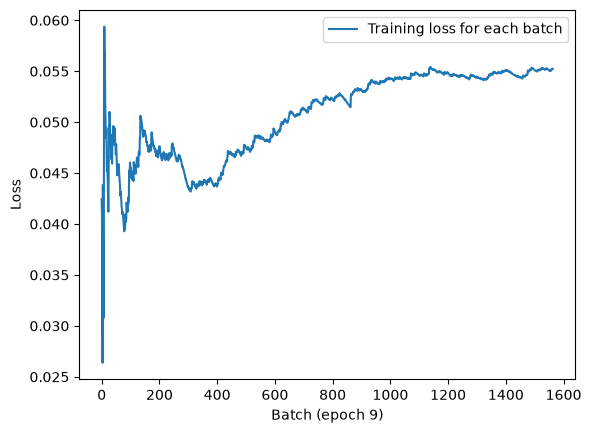

In [41]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=[LossHistory()],
    validation_data=(val_images, val_labels),
)

#### Monitoring and visualization with TensorBoard

In [42]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

tensorboard = keras.callbacks.TensorBoard(
    log_dir="./chapter07_log",
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels),
    callbacks=[tensorboard],
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9124 - loss: 0.2928 - val_accuracy: 0.9599 - val_loss: 0.1327
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 729us/step - accuracy: 0.9545 - loss: 0.1479 - val_accuracy: 0.9718 - val_loss: 0.0993
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.9637 - loss: 0.1177 - val_accuracy: 0.9750 - val_loss: 0.0886
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step - accuracy: 0.9690 - loss: 0.0970 - val_accuracy: 0.9760 - val_loss: 0.0837
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - accuracy: 0.9728 - loss: 0.0843 - val_accuracy: 0.9795 - val_loss: 0.0714
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.9761 - loss: 0.0742 - val_accuracy: 0.9784 - val_loss: 0.0732
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 728us/step - accuracy: 0.9776 - loss: 0.0677 - val_accuracy: 0.9785 - val_loss: 0.0723
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step - accuracy: 0.9786 - l

### Writing your own training and evaluation loops

#### Training vs. inference

#### Writing custom training step functions

##### A TensorFlow training step function

In [43]:
%%backend tensorflow
import tensorflow as tf

model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)
    optimizer.apply(gradients, model.trainable_weights)
    return loss

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


In [44]:
%%backend tensorflow
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]
loss = train_step(inputs, targets)

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


##### A PyTorch training step function

In [45]:
%%backend torch
import torch

model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    predictions = model(inputs, training=True)
    loss = loss_fn(targets, predictions)
    loss.backward()
    gradients = [weight.value.grad for weight in model.trainable_weights]
    with torch.no_grad():
        optimizer.apply(gradients, model.trainable_weights)
    model.zero_grad()
    return loss

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


In [46]:
%%backend torch
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]
loss = train_step(inputs, targets)

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


##### A JAX training step function

In [47]:
%%backend jax
model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()

def compute_loss_and_updates(
    trainable_variables, non_trainable_variables, inputs, targets
):
    outputs, non_trainable_variables = model.stateless_call(
        trainable_variables, non_trainable_variables, inputs, training=True
    )
    loss = loss_fn(targets, outputs)
    return loss, non_trainable_variables

In [48]:
%%backend jax
import jax

grad_fn = jax.value_and_grad(compute_loss_and_updates, has_aux=True)

In [49]:
%%backend jax
optimizer = keras.optimizers.Adam()
optimizer.build(model.trainable_variables)

def train_step(state, inputs, targets):
    (trainable_variables, non_trainable_variables, optimizer_variables) = state
    (loss, non_trainable_variables), grads = grad_fn(
        trainable_variables, non_trainable_variables, inputs, targets
    )
    trainable_variables, optimizer_variables = optimizer.stateless_apply(
        optimizer_variables, grads, trainable_variables
    )
    return loss, (
        trainable_variables,
        non_trainable_variables,
        optimizer_variables,
    )

In [50]:
%%backend jax
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]

trainable_variables = [v.value for v in model.trainable_variables]
non_trainable_variables = [v.value for v in model.non_trainable_variables]
optimizer_variables = [v.value for v in optimizer.variables]

state = (trainable_variables, non_trainable_variables, optimizer_variables)
loss, state = train_step(state, inputs, targets)

#### Low-level usage of metrics

In [51]:
from keras import ops

metric = keras.metrics.SparseCategoricalAccuracy()
targets = ops.array([0, 1, 2])
predictions = ops.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
metric.update_state(targets, predictions)
current_result = metric.result()
print(f"result: {current_result:.2f}")

result: 1.00


In [52]:
values = ops.array([0, 1, 2, 3, 4])
mean_tracker = keras.metrics.Mean()
for value in values:
    mean_tracker.update_state(value)
print(f"Mean of values: {mean_tracker.result():.2f}")

Mean of values: 2.00


In [53]:
metric = keras.metrics.SparseCategoricalAccuracy()
targets = ops.array([0, 1, 2])
predictions = ops.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

metric_variables = metric.variables
metric_variables = metric.stateless_update_state(
    metric_variables, targets, predictions
)
current_result = metric.stateless_result(metric_variables)
print(f"result: {current_result:.2f}")

metric_variables = metric.stateless_reset_state()

result: 1.00


#### Using fit() with a custom training loop

##### Customizing fit() with TensorFlow

In [54]:
%%backend tensorflow
import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = loss_fn(targets, predictions)
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply(gradients, self.trainable_weights)

        loss_tracker.update_state(loss)
        return {"loss": loss_tracker.result()}

    @property
    def metrics(self):
        return [loss_tracker]

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


In [55]:
%%backend tensorflow
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


In [56]:
%%backend tensorflow
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


##### Customizing fit() with PyTorch

In [57]:
%%backend torch
import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        predictions = self(inputs, training=True)
        loss = loss_fn(targets, predictions)

        loss.backward()
        trainable_weights = [v for v in self.trainable_weights]
        gradients = [v.value.grad for v in trainable_weights]

        with torch.no_grad():
            self.optimizer.apply(gradients, trainable_weights)

        loss_tracker.update_state(loss)
        return {"loss": loss_tracker.result()}

    @property
    def metrics(self):
        return [loss_tracker]

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


In [58]:
%%backend torch
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


In [59]:
%%backend torch
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


##### Customizing fit() with JAX

In [60]:
%%backend jax
import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = loss_fn(targets, predictions)
        return loss, non_trainable_variables

    def train_step(self, state, data):
        (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        ) = state
        inputs, targets = data

        grad_fn = jax.value_and_grad(
            self.compute_loss_and_updates, has_aux=True
        )

        (loss, non_trainable_variables), grads = grad_fn(
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )

        (
            trainable_variables,
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        logs = {"loss": loss}
        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        )
        return logs, state

In [61]:
%%backend jax
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

In [62]:
%%backend jax
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step - loss: 0.0000e+00
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - loss: 0.0000e+00
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - loss: 0.0000e+00


#### Handling metrics in a custom train_step()

##### train_step() metrics handling with TensorFlow

In [63]:
%%backend tensorflow
import keras
from keras import layers

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = self.compute_loss(y=targets, y_pred=predictions)

        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply(gradients, self.trainable_weights)

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


In [64]:
%%backend tensorflow
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

This cell requires the tensorflow backend. To run it, change KERAS_BACKEND to "tensorflow" at the top of the notebook, restart the runtime, and rerun the notebook.


##### train_step() metrics handling with PyTorch

In [65]:
%%backend torch
import keras
from keras import layers

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        predictions = self(inputs, training=True)
        loss = self.compute_loss(y=targets, y_pred=predictions)

        loss.backward()
        trainable_weights = [v for v in self.trainable_weights]
        gradients = [v.value.grad for v in trainable_weights]

        with torch.no_grad():
            self.optimizer.apply(gradients, trainable_weights)

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


In [66]:
%%backend torch
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

This cell requires the torch backend. To run it, change KERAS_BACKEND to "torch" at the top of the notebook, restart the runtime, and rerun the notebook.


##### train_step() metrics handling with JAX

In [67]:
%%backend jax
import keras
from keras import layers

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = self.compute_loss(y=targets, y_pred=predictions)
        return loss, (predictions, non_trainable_variables)

    def train_step(self, state, data):
        (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        ) = state
        inputs, targets = data

        grad_fn = jax.value_and_grad(
            self.compute_loss_and_updates, has_aux=True
        )

        (loss, (predictions, non_trainable_variables)), grads = grad_fn(
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )
        (
            trainable_variables,
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        new_metrics_vars = []
        logs = {}
        for metric in self.metrics:
            num_prev = len(new_metrics_vars)
            num_current = len(metric.variables)
            current_vars = metrics_variables[num_prev : num_prev + num_current]
            if metric.name == "loss":
                current_vars = metric.stateless_update_state(current_vars, loss)
            else:
                current_vars = metric.stateless_update_state(
                    current_vars, targets, predictions
                )
            logs[metric.name] = metric.stateless_result(current_vars)
            new_metrics_vars += current_vars

        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            new_metrics_vars,
        )
        return logs, state

## Exercise: Multi-input, multi-output model with difficulty output

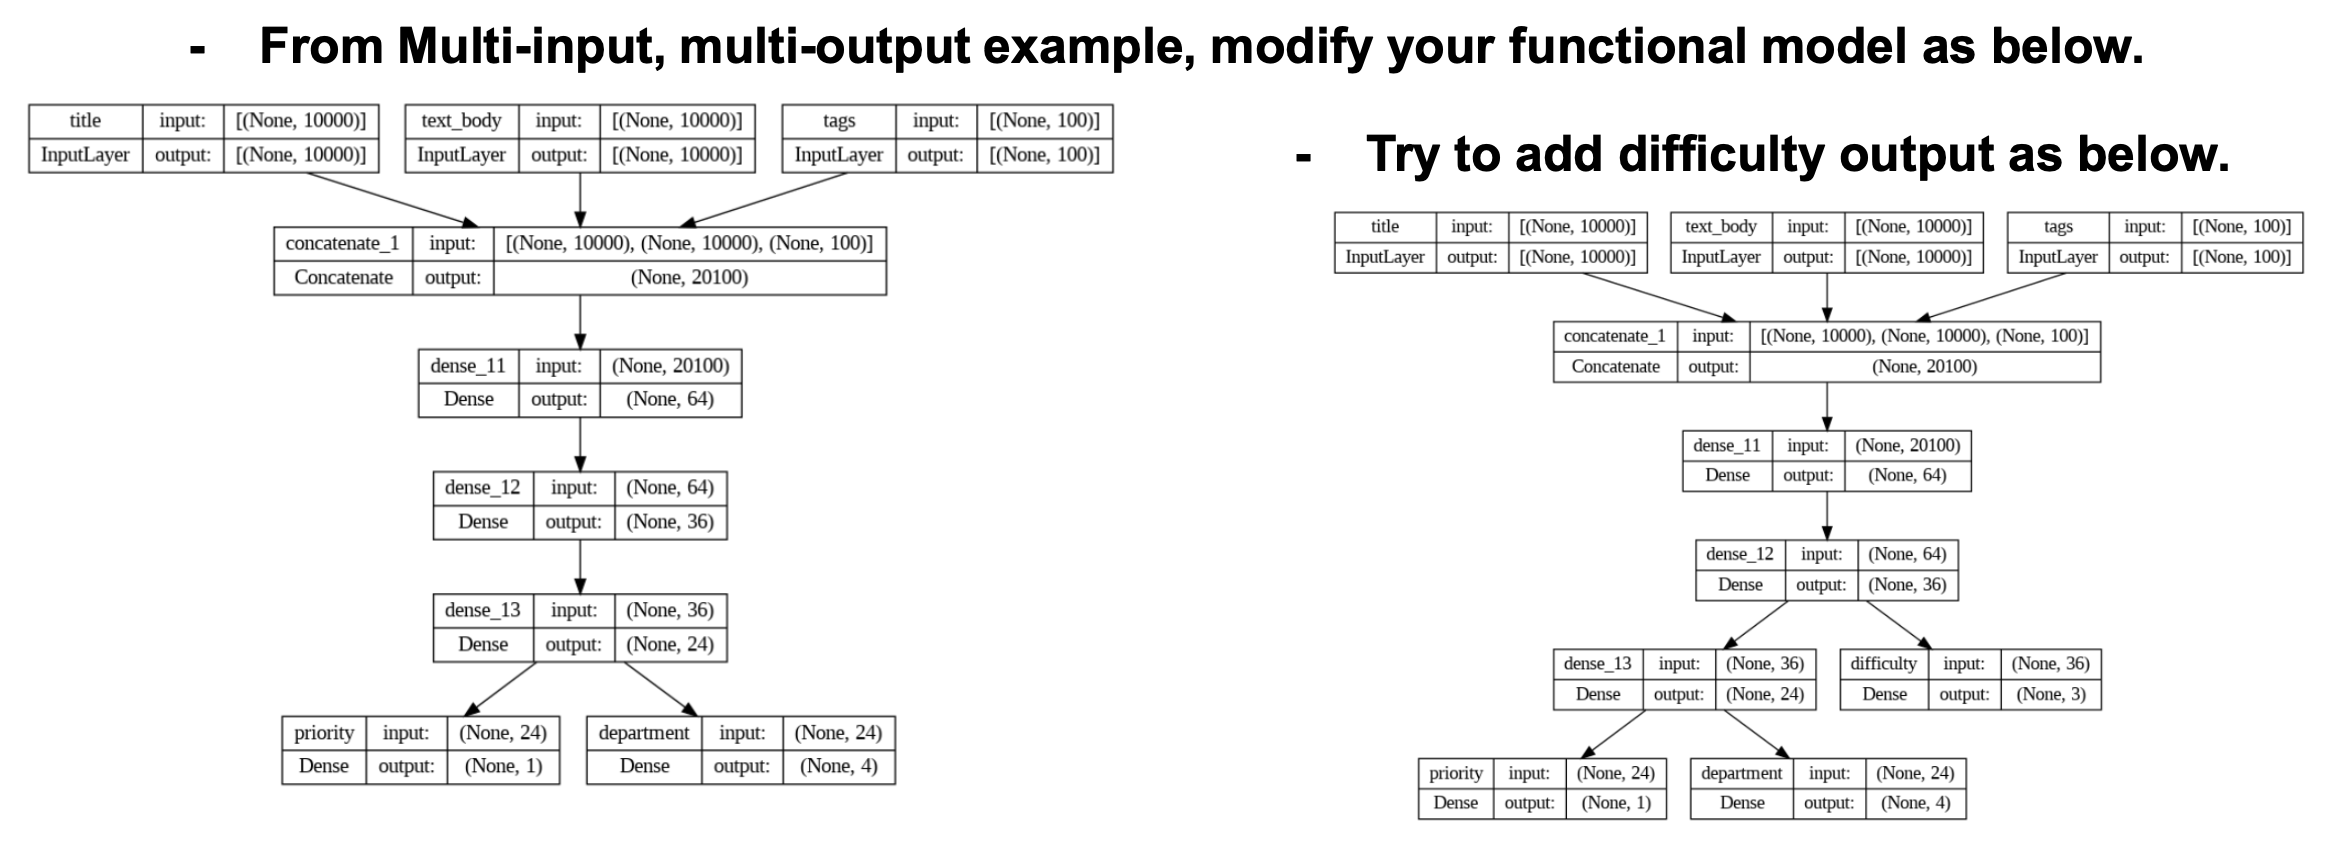

In [68]:
features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu")(features)
features = layers.Dense(36, activation="relu")(features)

hidden = layers.Dense(24, activation="relu")(features)
priority = layers.Dense(1, activation="sigmoid", name="priority")(hidden)
department = layers.Dense(
    num_departments, activation="softmax", name="department"
)(hidden)
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

exercise_model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department, difficulty],
)
keras.utils.plot_model(exercise_model, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
